In [1]:
import numpy as np
import pandas as pd
import altair as alt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()
from bokeh.plotting import figure, show

In [2]:
pd.options.display.max_columns = 500
pd.options.display.max_rows = 500
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [3]:
from clickhouse_driver import Client as Clickhouse
from uuid import uuid4
from pathlib import Path

def click_query(q, params=None):
    click = Clickhouse("localhost")
    query_id = f"oonidata-{uuid4()}"
    print(f"Starting query_id: {query_id}")
    return click.query_dataframe(q, params=params, query_id=query_id)

In [4]:
click_query("SELECT * FROM obs_web LIMIT 1").columns

Starting query_id: oonidata-82f41f50-6f67-4898-b12a-2091cd47aff3


Index(['measurement_uid', 'observation_idx', 'input', 'report_id',
       'ooni_run_link_id', 'measurement_start_time', 'software_name',
       'software_version', 'test_name', 'test_version', 'bucket_date',
       'probe_asn', 'probe_cc', 'probe_as_org_name', 'probe_as_cc',
       'probe_as_name', 'network_type', 'platform', 'origin', 'engine_name',
       'engine_version', 'architecture', 'resolver_ip', 'resolver_asn',
       'resolver_cc', 'resolver_as_org_name', 'resolver_as_cc',
       'resolver_is_scrubbed', 'resolver_asn_probe',
       'resolver_as_org_name_probe', 'created_at', 'target_id', 'hostname',
       'transaction_id', 'ip', 'port', 'ip_asn', 'ip_as_org_name', 'ip_as_cc',
       'ip_cc', 'ip_is_bogon', 'dns_query_type', 'dns_failure', 'dns_engine',
       'dns_engine_resolver_address', 'dns_answer_type', 'dns_answer',
       'dns_answer_asn', 'dns_answer_as_org_name', 'dns_t', 'tcp_failure',
       'tcp_success', 'tcp_t', 'tls_failure', 'tls_server_name',
       'tls_ou

In [18]:
df_echcheck = click_query("""
SELECT
measurement_uid,
probe_asn,
probe_cc,
software_name,
software_version,
test_name,
test_version,
measurement_start_time,
ip,
dns_failure,
tcp_failure,
tcp_success,
tls_failure,
tls_server_name,
tls_outer_server_name,
tls_echconfig,
tls_version
FROM obs_web
WHERE test_name = 'echcheck'
AND measurement_start_time > '2025-02-01'
AND test_version = '0.3.0'
""")

Starting query_id: oonidata-ce53c5b7-b551-4e18-b98a-071468204572


In [21]:
df_echcheck[['measurement_start_time', 'test_version']].groupby('test_version').count()

,measurement_start_time
test_version,
0.3.0,10399102


In [93]:
%%time
df_echcheck_grouped = click_query("""
SELECT
COUNT() as cnt,
--probe_asn,
probe_cc,
toStartOfDay(measurement_start_time) as ts,
-- 
multiIf(
    dns_failure IS NOT NULL, 'dns_fail',
    tcp_failure IS NOT NULL, 'tcp_fail',
    tls_failure IS NOT NULL, 'tls_fail',
    'ok'
) as outcome,
tls_server_name,
IF(
    tls_outer_server_name = '' OR tls_outer_server_name IS NULL, 
    tls_server_name, 
    tls_outer_server_name
) as outer_server_name,
multiIf(
    tls_echconfig = '', 'NONE', 
    tls_echconfig = 'GREASE', 
    'GREASE', 
    'REAL'
) as tls_echtype
FROM obs_web
WHERE test_name = 'echcheck'
AND measurement_start_time > '2025-02-01'
AND outer_server_name IN ('cloudflare-ech.com', '', 'cloudflare.com')
GROUP BY tls_server_name, 
    outcome, 
    tls_echtype, 
    ts,
    --probe_asn,
    probe_cc,
    outer_server_name
""")

Starting query_id: oonidata-73c2c790-2e07-4e34-8cc7-a4c1eff085fc
CPU times: user 690 ms, sys: 12 ms, total: 702 ms
Wall time: 28.1 s


In [94]:
df_echcheck_grouped['outer_server_name'].unique()

array(['cloudflare-ech.com', 'cloudflare.com'], dtype=object)

In [96]:
df_echcheck_grouped['tls_server_name'].unique()

array(['cloudflare-ech.com'], dtype=object)

In [97]:
df_echcheck_grouped['tls_echtype'].unique()

array(['REAL', 'GREASE', 'NONE'], dtype=object)

In [84]:
df_echcheck_grouped.columns

Index(['cnt', 'probe_cc', 'ts', 'outcome', 'tls_server_name',
       'outer_server_name', 'tls_echtype'],
      dtype='object')

In [85]:
df_echcheck_grouped['outer_server_name'].unique()

array(['', 'cloudflare-ech.com'], dtype=object)

In [81]:
df_echcheck_grouped['tls_echtype'].unique()

array(['NONE', 'REAL', 'GREASE'], dtype=object)

In [100]:
df_echcheck_grouped['probe_cc'].unique()

array(['KR', 'HU', 'NL', 'PH', 'SG', 'RO', 'PR', 'SK', 'EC', 'BR', 'BG',
       'VE', 'MX', 'LB', 'RU', 'BH', 'BY', 'BA', 'JP', 'IT', 'KH', 'SE',
       'PK', 'AE', 'PL', 'BO', 'JO', 'SN', 'MA', 'TR', 'SY', 'MZ', 'AZ',
       'TN', 'CL', 'HR', 'MM', 'AU', 'LT', 'CI', 'IR', 'AQ', 'IL', 'DK',
       'CH', 'PY', 'LU', 'NZ', 'ZW', 'ME', 'DZ', 'IN', 'PT', 'AM', 'CA',
       'PE', 'BE', 'BD', 'US', 'MY', 'LK', 'GY', 'KG', 'DE', 'IQ', 'ID',
       'SI', 'GH', 'TG', 'ZA', 'GA', 'TW', 'EE', 'PS', 'AR', 'TH', 'KW',
       'NI', 'TZ', 'AL', 'KE', 'CY', 'MT', 'YE', 'GB', 'AX', 'CM', 'FR',
       'BI', 'IE', 'NG', 'ET', 'LA', 'FI', 'VN', 'AT', 'GE', 'ZM', 'LV',
       'CZ', 'GQ', 'NO', 'GR', 'SA', 'MU', 'MN', 'HK', 'RS', 'KZ', 'HN',
       'BF', 'LS', 'MK', 'DO', 'CO', 'BQ', 'EG', 'JM', 'SV', 'LY', 'ES',
       'UZ', 'OM', 'UG', 'MR', 'LC', 'CR', 'CN', 'UA', 'MG', 'SR', 'NA',
       'CD', 'AO', 'MD', 'AF', 'PF', 'CV', 'BJ', 'IS', 'NP', 'GN', 'GT',
       'KY', 'LR', 'MV', 'PA', 'UY', 'GP', 'MO', 'G

In [102]:
alt.Chart(df_echcheck_grouped[
          df_echcheck_grouped['probe_cc'] == 'RU'
          ]).mark_bar().encode(
    y='cnt',
    x='ts',
    column='outer_server_name',
    row='tls_echtype',
    color='outcome',
    tooltip=['ts', 'cnt', 'outcome', 'tls_echtype']
).properties(
    width=800,
    height=100,
    title=f'ECH Outcome in Russia Feb - Oct 2025'
)

alt.Chart(...)

In [101]:
for cc in df_echcheck_grouped['probe_cc'].unique():
    alt.Chart(df_echcheck_grouped[
              df_echcheck_grouped['probe_cc'] == cc
              ]).mark_bar().encode(
        y='cnt',
        x='ts',
        column='outer_server_name',
        row='tls_echtype',
        color='outcome',
        tooltip=['ts', 'cnt', 'outcome', 'tls_echtype']
    ).properties(
        width=800,
        height=100,
        title=f'ECH Outcome in {cc} Feb - Oct 2025'
    ).save(f'chart-{cc}.png')

In [68]:
np.append(df_echcheck_grouped['probe_cc'].unique()[:10], 'RU')

array(['AR', 'RO', 'IN', 'AT', 'SI', 'CH', 'NO', 'GE', 'LT', 'ZA', 'RU'],
      dtype=object)

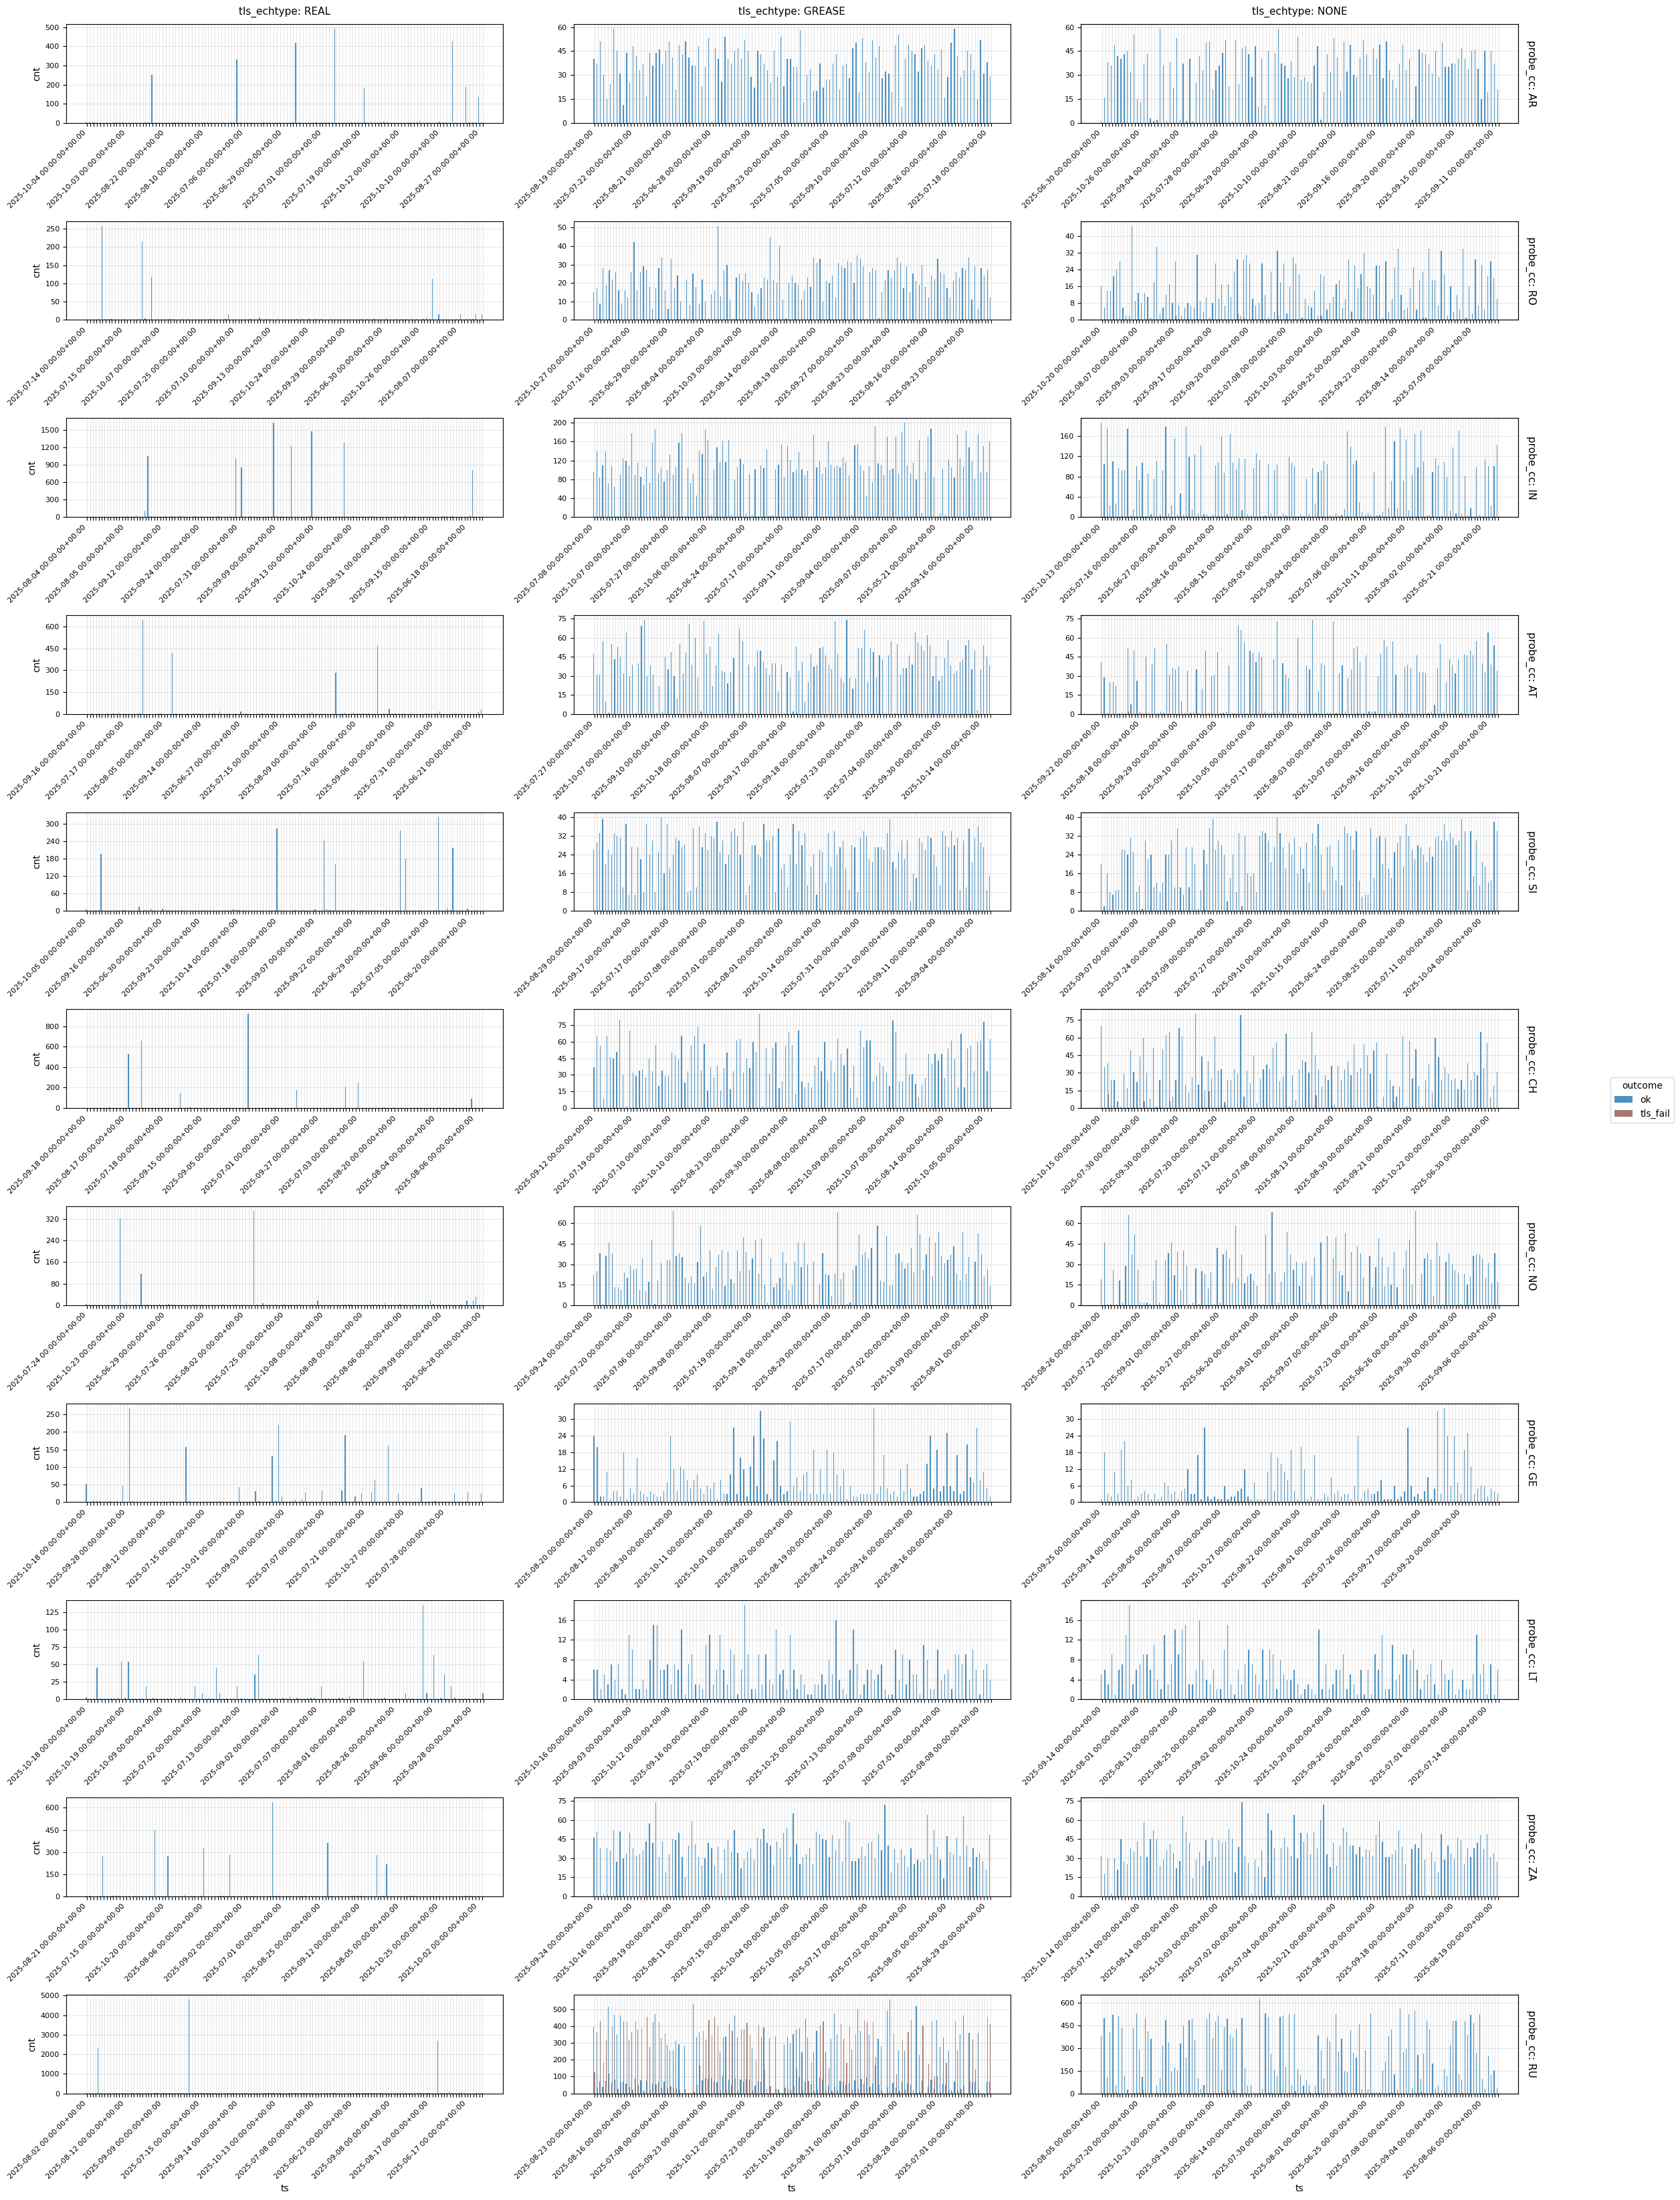

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Get unique values for faceting
probe_ccs = np.append(df_echcheck_grouped['probe_cc'].unique()[:10], 'RU')
tls_echtypes = df_echcheck_grouped['tls_echtype'].unique()
outcomes = df_echcheck_grouped['outcome'].unique()

# Create color map for outcomes
colors = plt.cm.tab10(np.linspace(0, 1, len(outcomes)))
color_map = dict(zip(outcomes, colors))

# Create figure with subplots
n_rows = len(probe_ccs)
n_cols = len(tls_echtypes)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 3 * n_rows), squeeze=False)

# Plot each facet
for i, probe_cc in enumerate(probe_ccs):
    for j, tls_echtype in enumerate(tls_echtypes):
        ax = axes[i, j]
        
        # Filter data for this facet
        mask = (df_echcheck_grouped['probe_cc'] == probe_cc) & \
               (df_echcheck_grouped['tls_echtype'] == tls_echtype)
        facet_data = df_echcheck_grouped[mask]
        
        # Plot each outcome as bars
        # Get unique timestamps for this facet
        unique_ts = facet_data['ts'].unique()
        x = np.arange(len(unique_ts))
        bar_width = 0.8 / len(outcomes)
        
        for idx, outcome in enumerate(outcomes):
            outcome_data = facet_data[facet_data['outcome'] == outcome]
            if len(outcome_data) > 0:
                # Create a mapping of ts to cnt
                ts_to_cnt = dict(zip(outcome_data['ts'], outcome_data['cnt']))
                counts = [ts_to_cnt.get(ts, 0) for ts in unique_ts]
                
                offset = (idx - len(outcomes)/2) * bar_width + bar_width/2
                ax.bar(x + offset, counts, bar_width, 
                      label=outcome, color=color_map[outcome], alpha=0.8)
        
        # Set x-axis to show timestamps with cleaner formatting
        ax.set_xticks(x)
        # Only show a subset of labels to avoid crowding
        num_labels = min(10, len(unique_ts))  # Show max 10 labels
        step = max(1, len(unique_ts) // num_labels)
        labels = [unique_ts[i] if i % step == 0 else '' for i in range(len(unique_ts))]
        ax.set_xticklabels(labels, rotation=45, ha='right')
        
        # Set labels
        if i == n_rows - 1:
            ax.set_xlabel('ts', fontsize=10)
        if j == 0:
            ax.set_ylabel('cnt', fontsize=10)
        
        # Add row/column titles
        if i == 0:
            ax.set_title(f'tls_echtype: {tls_echtype}', fontsize=11, pad=10)
        if j == n_cols - 1:
            ax2 = ax.twinx()
            ax2.set_ylabel(f'probe_cc: {probe_cc}', fontsize=11, rotation=270, labelpad=20)
            ax2.set_yticks([])
        
        # Rotate x-axis labels if they're dates
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))  # Limit y-axis ticks
        ax.grid(True, alpha=0.3)

# Add legend (outside the subplots)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.05, 0.5), 
          title='outcome', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.95)  # Make room for legend
plt.show()